<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L03-ETSDA/notebooks/L03_1_Descomposicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
from google.colab import files
files.upload()

Saving pas.csv to pas (4).csv


{'pas (4).csv': b'Periodo,Pasajeros\r\n1,112\r\n2,118\r\n3,132\r\n4,129\r\n5,121\r\n6,135\r\n7,148\r\n8,148\r\n9,136\r\n10,119\r\n11,104\r\n12,118\r\n13,115\r\n14,126\r\n15,141\r\n16,135\r\n17,125\r\n18,149\r\n19,170\r\n20,170\r\n21,158\r\n22,133\r\n23,114\r\n24,140\r\n25,145\r\n26,150\r\n27,178\r\n28,163\r\n29,172\r\n30,178\r\n31,199\r\n32,199\r\n33,184\r\n34,162\r\n35,146\r\n36,166\r\n37,171\r\n38,180\r\n39,193\r\n40,181\r\n41,183\r\n42,218\r\n43,230\r\n44,242\r\n45,209\r\n46,191\r\n47,172\r\n48,194\r\n49,196\r\n50,196\r\n51,236\r\n52,235\r\n53,229\r\n54,243\r\n55,264\r\n56,272\r\n57,237\r\n58,211\r\n59,180\r\n60,201\r\n61,204\r\n62,188\r\n63,235\r\n64,227\r\n65,234\r\n66,264\r\n67,302\r\n68,293\r\n69,259\r\n70,229\r\n71,203\r\n72,229\r\n73,242\r\n74,233\r\n75,267\r\n76,269\r\n77,270\r\n78,315\r\n79,364\r\n80,347\r\n81,312\r\n82,274\r\n83,237\r\n84,278\r\n85,284\r\n86,277\r\n87,317\r\n88,313\r\n89,318\r\n90,374\r\n91,413\r\n92,405\r\n93,355\r\n94,306\r\n95,271\r\n96,306\r\n97,315\r\n

In [3]:
df = pd.read_csv("/content/pas.csv")
df

,Periodo,Pasajeros
0,1,112
1,2,118
2,3,132
3,4,129
4,5,121
...,...,...
139,140,606
140,141,508
141,142,461
142,143,390


In [4]:
df['Fecha'] = pd.period_range(start='1949-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df = df.drop(columns=['Periodo'])
# Convertir a índice Datetime para compatibilidad con descomposición
df.index = df.index.to_timestamp()
df.head()

,Pasajeros
Fecha,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


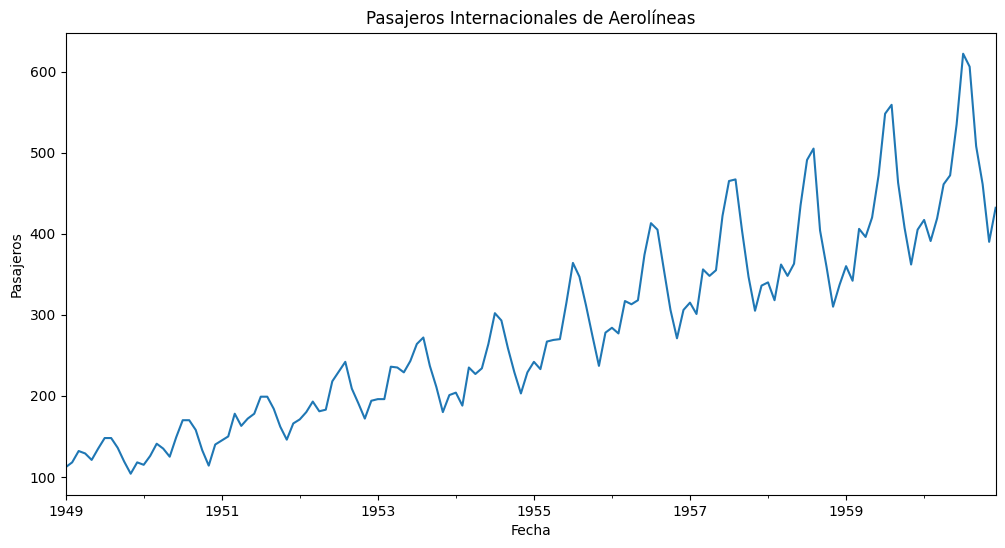

In [5]:
plt.figure(figsize=(12, 6))
df['Pasajeros'].plot()
plt.title('Pasajeros Internacionales de Aerolíneas')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.show()

<Figure size 1200x800 with 0 Axes>

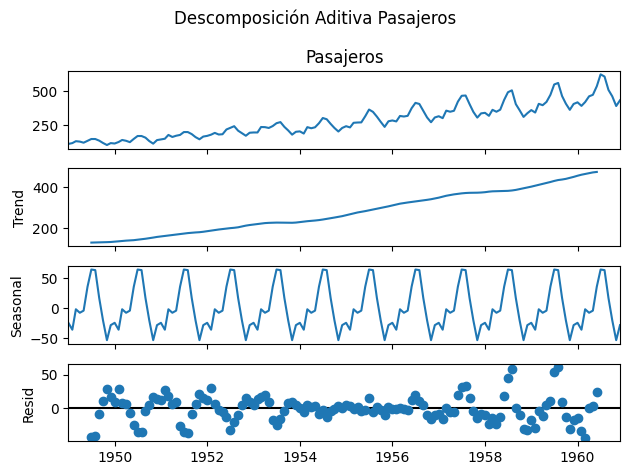

In [6]:
# Descomposición Aditiva
pasDecomA = seasonal_decompose(df['Pasajeros'], model='additive')

# Gráfica de la descomposición
plt.figure(figsize=(12, 8))
pasDecomA.plot()
plt.suptitle('Descomposición Aditiva Pasajeros')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

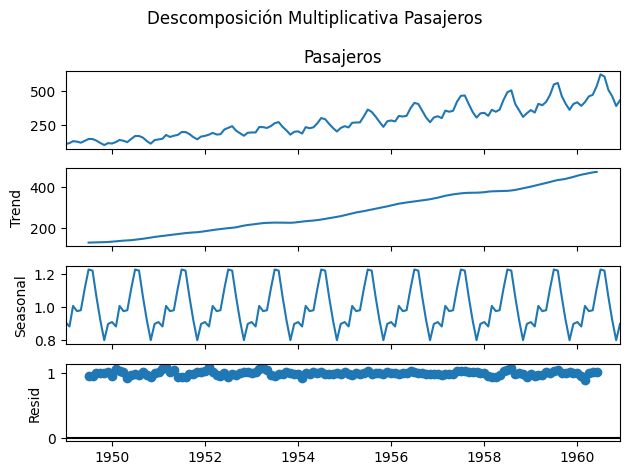

In [7]:
# Descomposición Multiplicativa
pasDecomM = seasonal_decompose(df['Pasajeros'],
                               model='multiplicative',
                               period = 12) # OJO: period no es necesario porque lo declaramos desde la ST

# Gráfica de la descomposición
plt.figure(figsize=(12, 8))
pasDecomM.plot()
plt.suptitle('Descomposición Multiplicativa Pasajeros')
plt.tight_layout()
plt.show()

In [8]:
df['Tendencia'] = pasDecomM.trend
df['Estacional'] = pasDecomM.seasonal
df['Residual'] = pasDecomM.resid
df['TendEst'] = df['Tendencia'] * df['Estacional']
df['Recomp'] = df['Tendencia'] * df['Estacional'] * df['Residual']

df.tail(12)

,Pasajeros,Tendencia,Estacional,Residual,TendEst,Recomp
Fecha,,,,,,
1960-01-01,417,456.333333,0.910230,1.003928,415.368458,417.0
1960-02-01,391,461.375000,0.883625,0.959079,407.682632,391.0
1960-03-01,419,465.208333,1.007366,0.894086,468.635192,419.0
1960-04-01,461,469.333333,0.975906,1.006495,458.025222,461.0
1960-05-01,472,472.750000,0.981378,1.017359,463.946462,472.0
1960-06-01,535,475.041667,1.112776,1.012079,528.614883,535.0
1960-07-01,622,NaN,1.226556,NaN,NaN,NaN
1960-08-01,606,NaN,1.219911,NaN,NaN,NaN
1960-09-01,508,NaN,1.060492,NaN,NaN,NaN


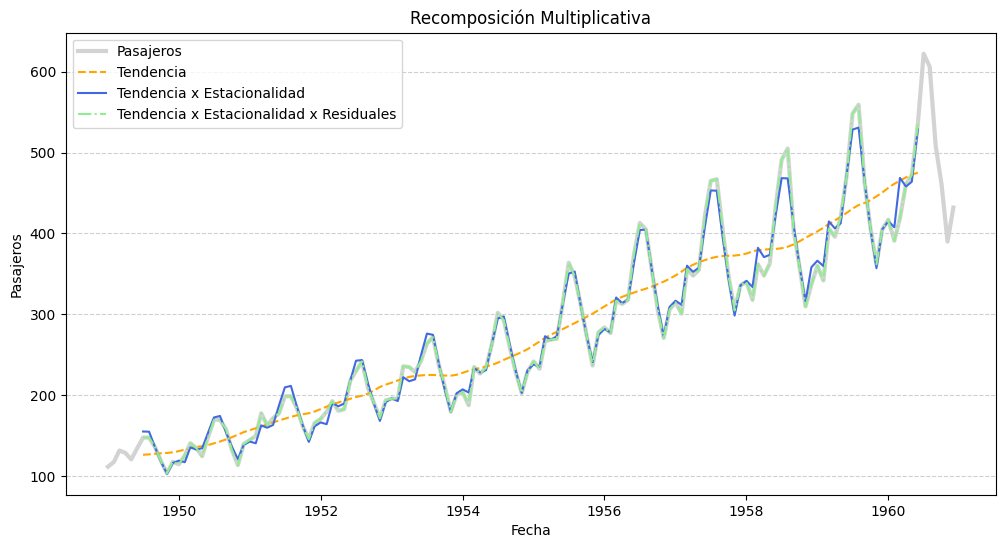

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df['Pasajeros'], label='Pasajeros', color = 'lightgray', lw = 3)
plt.plot(df['Tendencia'], label='Tendencia', color ='orange', linestyle = '--')
plt.plot(df['TendEst'], label='Tendencia x Estacionalidad', color = 'royalblue')
# Descomentar para ver la recomposición multiplicativa de los 3 elementos
plt.plot(df['Recomp'], label='Tendencia x Estacionalidad x Residuales', color = 'lightgreen', linestyle = '-.')

# Etiquetas
plt.title('Recomposición Multiplicativa')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# **Calentamiento global**

In [10]:
from google.colab import files
files.upload()

Saving global.dat to global (2).dat


{'global (2).dat': b'-0.384 -0.457 -0.673 -0.344 -0.311 -0.071 -0.246 -0.235 -0.380 -0.418 -0.670 -0.386 \n-0.437 -0.150 -0.528 -0.692 -0.629 -0.363 -0.375 -0.328 -0.495 -0.646 -0.754 -0.137 \n-0.452 -1.031 -0.643 -0.328 -0.311 -0.263 -0.248 -0.274 -0.203 -0.121 -0.913 -0.197 \n-0.249 -0.041 -0.082 -0.172 -0.085 -0.278 -0.220 -0.132 -0.436 -0.234 -0.288 -0.486 \n-0.070 -0.526 -0.599 -0.420 -0.273 -0.063 -0.182 -0.256 -0.213 -0.326 -0.696 -0.813 \n-0.858 -0.415 -0.431 -0.443 -0.735 -0.169 -0.227 -0.131 -0.377 -0.375 -0.434 -0.209 \n-0.711 -0.817 -0.435 -0.232 -0.194 -0.322 -0.466 -0.623 -0.345 -0.382 -0.932 -0.768 \n 0.263 -0.063 -0.379 -0.187 -0.320 -0.365 -0.510 -0.359 -0.291 -0.431 -0.362 -0.276 \n-0.834 -0.604 -0.516 -0.482 -0.399 -0.200 -0.138 -0.332 -0.394 -0.711 -0.507 -0.587 \n-0.125 -0.615 -0.597 -0.135 -0.152 -0.227 -0.153 -0.267  0.002 -0.358 -0.200 -0.324 \n 0.095 -0.173 -0.396 -0.119 -0.533  0.078 -0.089 -0.282 -0.224 -0.364 -0.294 -0.368 \n-0.306  0.087 -0.665 -0.235 -0.45

In [11]:
# OJO con esta conversión de datos
dfCal = pd.read_csv('/content/global.dat', sep='\s+', header=None, skipinitialspace=True) # separador de uno o más espacios
dfCal = df.stack().reset_index(drop=True).to_frame(name='Temperatura') # convertir en un df largo de una sola columna
dfCal

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_27174/1548630392.py:2: SyntaxWarning: invalid escape sequence '\s'
  dfCal = pd.read_csv('/content/global.dat', sep='\s+', header=None, skipinitialspace=True) # separador de uno o más espacios


,Temperatura
0,112.000000
1,0.910230
2,118.000000
3,0.883625
4,132.000000
...,...
811,0.921757
812,390.000000
813,0.801178
814,432.000000


In [12]:
dfCal['Fecha'] = pd.period_range(start='1856-01', periods=len(dfCal), freq='M')
dfCal = dfCal.set_index('Fecha')
# Convertir a índice Datetime para compatibilidad con descomposición
dfCal.index = dfCal.index.to_timestamp()
dfCal.head()

,Temperatura
Fecha,
1856-01-01,112.000000
1856-02-01,0.910230
1856-03-01,118.000000
1856-04-01,0.883625
1856-05-01,132.000000
